In [1]:
import pandas as pd

In [3]:
infer = pd.read_csv('merged_results.csv')
res = pd.read_csv('advanced_results_Group_buzz.csv')

In [9]:
infer['filename']= infer['name']
infer['start_time'] = infer['start']

a = pd.merge(infer, res, on=['filename', 'start_time'], how='inner')

In [17]:
import numpy as np

# vrai positif
tp = a.loc[np.logical_and(a['used_threshold'] < a['score'], a['ground_truth'] == 1)]
# vrai negatif
tn = a.loc[np.logical_and(a['score'] < a['used_threshold'], a['ground_truth'] == 0)]
# faux negatif
fn = a.loc[np.logical_and(a['score'] < a['used_threshold'], a['ground_truth'] == 1)]
# faux positif
fp = a.loc[np.logical_and(a['used_threshold'] < a['score'], a['ground_truth'] == 0)]

In [37]:
scor_col = ['tag_fly_housefly',
       'tag_bee_wasp', 'tag_fly_bee_wasp', 'tag_water', 'tag_wind',
       'tag_motor_vehicle', 'tag_aircraft', 'tag_human_voice', 'Group_buzz',
       'Group_geophony', 'Group_anthropophony']

fn[scor_col].iloc[-3]

tag_fly_housefly       0.079364
tag_bee_wasp           0.122414
tag_fly_bee_wasp       0.122414
tag_water              0.007978
tag_wind               0.011333
tag_motor_vehicle      0.022942
tag_aircraft           0.002390
tag_human_voice        0.069483
Group_buzz             0.122414
Group_geophony         0.011333
Group_anthropophony    0.069483
Name: 3981, dtype: float64

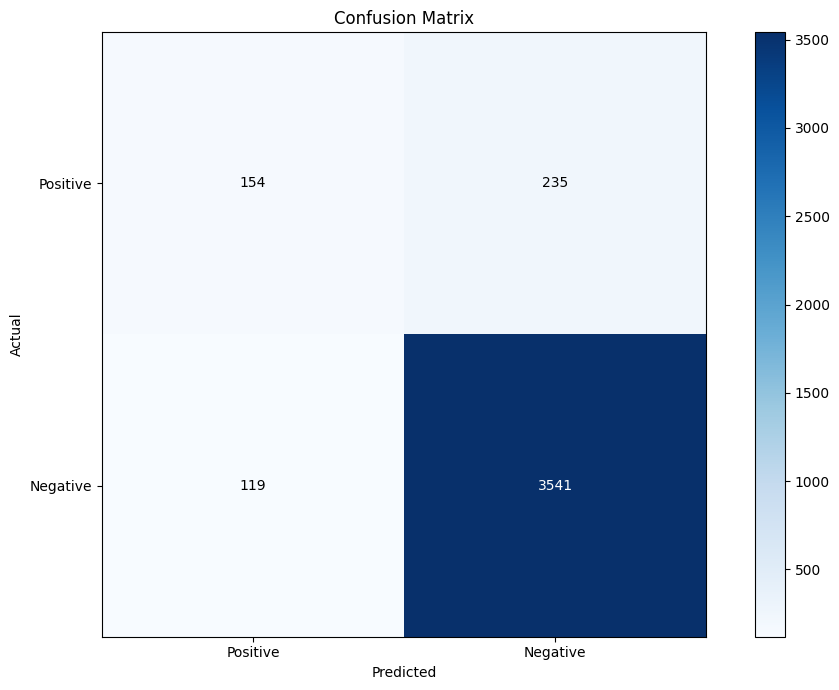

In [24]:
# plot confusion matrix:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Confusion Matrix")
confusion_matrix = np.array([[tp.shape[0], fn.shape[0]], [fp.shape[0], tn.shape[0]]])
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ['Positive', 'Negative'])
plt.yticks([0, 1], ['Positive', 'Negative'])
plt.tight_layout()
for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_matrix[i, j], ha='center', va='center', color='white' if confusion_matrix[i, j] > confusion_matrix.max() / 2 else 'black')
plt.colorbar()